In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2
from scipy.stats import chi2


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

# 1. Поляризация

In [138]:
d_h = 0.5
d_beta = 1
data1 = pd.read_excel("измерения.xlsx", sheet_name="поляризация")[["beta, градусов", "h1", "h2",	"h3",	"h4"]].dropna()
data1["beta"] = data1["beta, градусов"]/180 * np.pi
data1["V"] = (data1["h4"] - data1["h3"])/(data1["h4"] + data1["h3"])
data1["d_V"] = (2 *(d_h/(data1["h4"] - data1["h3"]))**2 +2 *(d_h/(data1["h4"] + data1["h3"]))**2)**0.5 * data1["V"]
data1["delta"] = data1["h1"]/data1["h2"]
data1["d_delta"] = ((d_h/data1["h1"])**2 + (d_h/data1["h2"])**2)**0.5 * data1["delta"]
data1["V1"] = 2 * data1["delta"]**0.5 / (1 + data1["delta"])
data1["d_V1"] = ((data1["d_delta"]/2/data1["delta"])**2 + (data1["d_delta"]/ (1 + data1["delta"]))**2)**0.5 * data1["V1"]
data1["V3"] = data1["V"]/data1["V1"]
data1["d_V3"] = ((data1["d_V"]/data1["V"])**2 + (data1["d_V1"]/data1["V1"])**2)**0.5 * data1["V3"]

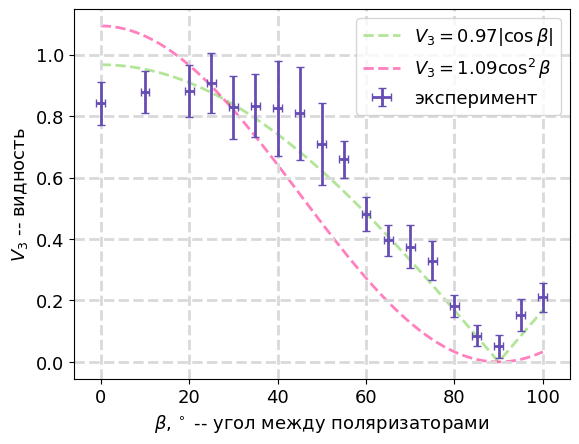

In [139]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.errorbar(data1["beta, градусов"], data1["V3"], 
             xerr = d_beta, yerr = data1["d_V3"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2,
             color = dark_purple,
             label = "эксперимент",
             zorder = 5)
beta_th = np.linspace(0, 100, 100)
plt.plot(beta_th, abs(k*np.cos(beta_th * np.pi/180)), 
         '--', color = light_green, 
         alpha = 0.5,
         label = r"$V_3 = $" + f"{k:.2f}" + r"$|\cos\beta|$",
         zorder = 0)
plt.plot(beta_th, k2*np.cos(beta_th * np.pi/180)**2, 
         '--', color = raspberry_pink, 
         alpha = 0.5,
         label = r"$V_3 = $" + f"{k2:.2f}" + r"$\cos^2\beta$",
         zorder = 0)
plt.xlabel(r"$\beta, ^\circ$ -- угол между поляризаторами")
plt.ylabel(r"$V_3$ -- видность")
plt.legend()
plt.savefig("pics/graph1_nolin.png", dpi = 300)

In [140]:
data1["cos"] = abs(np.cos(data1["beta"]))
data1["d_cos"] = abs(np.sin(data1["beta"])) * d_beta /180 * np.pi
data1["cos2"] = np.cos(data1["beta"])**2
data1["d_cos2"] = abs(np.sin(2*data1["beta"])) * d_beta /180 * np.pi
pd.set_option('display.precision', 2)
data1[["beta, градусов", "V3", "d_V3"]].sort_values(by = "beta, градусов")

,"beta, градусов",V3,d_V3
0,0.0,0.84,0.07
16,10.0,0.88,0.07
15,20.0,0.88,0.08
14,25.0,0.91,0.10
13,30.0,0.83,0.10
12,35.0,0.83,0.10
11,40.0,0.82,0.15
10,45.0,0.81,0.15
9,50.0,0.71,0.13
8,55.0,0.66,0.06


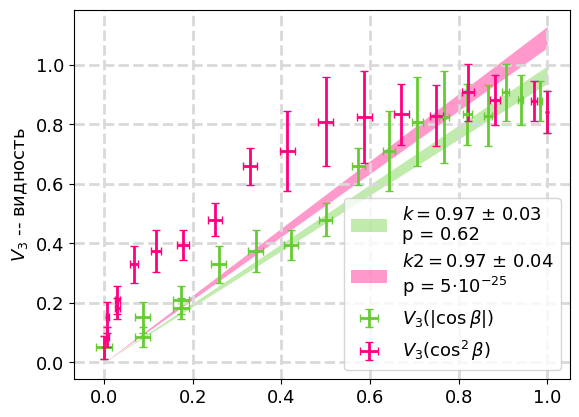

In [141]:
def linear0(x, k):
    return k*x
popt, pcov = opt.curve_fit(linear0, 
                             data1["cos"], 
                             data1["V3"], 
                             sigma = data1["d_V3"], 
                             absolute_sigma = True)
k = popt[0]
d_k = pcov[0][0]**0.5
chi2_value = np.sum(((data1["V3"] - data1["cos"] * k)/data1["d_V3"])**2)
p = chi2.sf(chi2_value, len(data1) - 1)


popt, pcov = opt.curve_fit(linear0, 
                             data1["cos2"], 
                             data1["V3"], 
                             sigma = data1["d_V3"], 
                             absolute_sigma = True)
k2 = popt[0]
d_k2 = pcov[0][0]**0.5
chi2_value = np.sum(((data1["V3"] - data1["cos2"] * k2)/data1["d_V3"])**2)
p2 = chi2.sf(chi2_value, len(data1) - 1)

cos_th = np.linspace(0, 1, 100)

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.errorbar(data1["cos"], data1["V3"], 
             xerr = data1["d_cos"], yerr = data1["d_V3"], 
             fmt = 'o', 
             capsize=3, 
             label = r"$V_3(|\cos\beta|)$",
             markersize = 2,
             color = light_green,
             zorder = 5)
plt.fill_between(cos_th, (k-d_k)*cos_th, (k+d_k)*cos_th,
        linewidth = 0,
         color = light_green, 
         alpha = 0.4, 
         label = r"$k = $" + f"{k:.2f}" + r" $\pm$ " + f"{d_k:.2f}\np = {p:.2f}",
         zorder = 0)

plt.errorbar(data1["cos2"], data1["V3"], 
             xerr = data1["d_cos2"], yerr = data1["d_V3"], 
             fmt = 'o', 
             capsize=3, 
             label = r"$V_3(\cos^2\beta)$",
             markersize = 2,
             color = raspberry_pink,
             zorder = 5)
plt.fill_between(cos_th, (k2-d_k2)*cos_th, (k2+d_k2)*cos_th,
        linewidth = 0,
         color = raspberry_pink, 
         alpha = 0.4, 
         label = r"$k2 = $" + f"{k:.2f}" + r" $\pm$ " + f"{d_k2:.2f}\np = {p2*1e25:.0f}" + r"$\cdot10^{-25}$",
         zorder = 0)
plt.ylabel(r"$V_3$ -- видность")
plt.legend()
plt.savefig("pics/graph1_lin.png", dpi = 300)

# Длина когерентности

In [171]:
d_x = 0.5
data2 = pd.read_excel("измерения.xlsx", sheet_name="длина когерентности")[["x, cm", "h1", "h2",	"h3",	"h4"]].dropna()
data2["l"] = data2["x, cm"]*2
data2["V"] = (data2["h4"] - data2["h3"])/(data2["h4"] + data2["h3"])
data2["d_V"] = (2 *(d_h/(data2["h4"] - data2["h3"]))**2 +2 *(d_h/(data2["h4"] + data2["h3"]))**2)**0.5 * data2["V"]
data2["delta"] = data2["h1"]/data2["h2"]
data2["d_delta"] = ((d_h/data2["h1"])**2 + (d_h/data2["h2"])**2)**0.5 * data2["delta"]
data2["V1"] = 2 * data2["delta"]**0.5 / (1 + data2["delta"])
data2["d_V1"] = ((data2["d_delta"]/2/data2["delta"])**2 + (data2["d_delta"]/ (1 + data2["delta"]))**2)**0.5 * data2["V1"]
data2["V2"] = data2["V"]/data2["V1"]
data2["d_V2"] = ((data2["d_V"]/data2["V"])**2 + (data2["d_V1"]/data2["V1"])**2)**0.5 * data2["V2"]
data2=data2.sort_values(by="l")

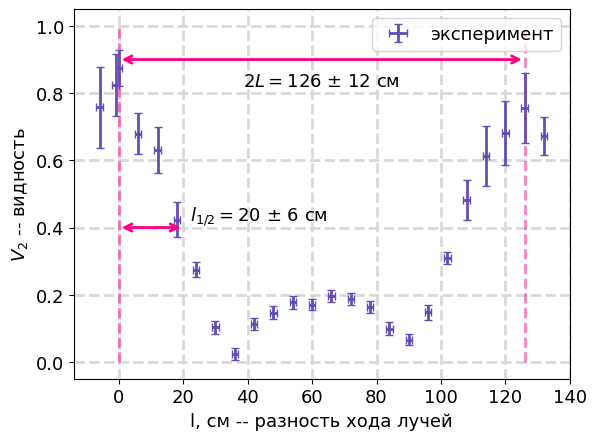

In [173]:
l_min = data2["l"].iloc[2]
l_max = data2["l"].iloc[-2]

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.errorbar(data2["l"]-l_min, data2["V2"], 
             xerr = d_x*2, yerr = data2["d_V2"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2,
             color = dark_purple,
             label = "эксперимент",
             zorder = 5)
plt.vlines([0, l_max-l_min], 0, 1, colors = raspberry_pink, alpha = 0.5, linestyles='--')

plt.annotate("",
             xy=(0, 0.9),  
             xytext=(l_max-l_min, 0.9),  
             arrowprops=dict(arrowstyle='<->', color=raspberry_pink, linewidth = 2))
plt.text((l_max - l_min)/2, 0.82, 
         r'$2L = $' + f"{l_max - l_min:.0f}" + r" $\pm$ 12 см", ha='center')

plt.annotate("",
             xy=(0, 0.4),  
             xytext=(20, 0.4),  
             arrowprops=dict(arrowstyle='<->', color=raspberry_pink, linewidth = 2),
             zorder = 5)
plt.text(22, 0.42, 
         r'$l_{1/2} = $' + f"{20:.0f}" + r" $\pm$ 6 см", ha='left')

plt.xlabel("l, см -- разность хода лучей")
plt.ylabel(r"$V_2$ -- видность")
plt.legend()
plt.savefig("pics/graph2.png", dpi = 300)

In [178]:
pd.set_option('display.precision', 2)
data2[["V2", "d_V2"]]

,V2,d_V2
1,0.76,0.12
0,0.82,0.09
2,0.87,0.05
3,0.68,0.06
4,0.63,0.07
5,0.42,0.05
6,0.27,0.02
7,0.10,0.02
8,0.02,0.02
9,0.11,0.02


In [161]:
l = 20 # см
d_l = 6 # см
L = 63/2
d_L = 6/2

delta_nu = 0.6 * 3 * 1e10/l
d_delta_nu = d_l/l * delta_nu

n = 1 + 1.2 * L/l
d_n = ((d_l/l)**2 + (d_L/L)**2)**0.5 * L/l * 1.2


delta_nu*1e-9, d_delta_nu*1e-9, n, d_n

(0.9, 0.27, 2.8899999999999997, 0.5948857033077866)